# 05.33 - Capstone: ML Synthesis Project

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Demonstrate mastery of all ML concepts by solving a real problem end-to-end.

## 2. Why Does This Matter?

The capstone proves you can apply ML to real-world problems. It is your portfolio piece.

## 3. Prerequisites

- All 32 previous notebooks in Phase 05

## 4. Learning Objectives

- Apply the full ML workflow to a real dataset
- Make and justify design decisions
- Build a reproducible pipeline
- Document your approach

## 5. Mental Model

Real ML = problem -> data -> features -> models -> evaluation -> deployment.
Every decision should be justified. Reproducibility is key.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib, os, warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Problem Definition

In [2]:
print("PROBLEM: Predict median house value in California")
print("GOAL: R2 > 0.75 on test set")
print("CONSTRAINTS: Must use only sklearn, must be reproducible")

PROBLEM: Predict median house value in California
GOAL: R2 > 0.75 on test set
CONSTRAINTS: Must use only sklearn, must be reproducible


## 7. Load and Explore

In [3]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["target"] = housing.target * 100000

print("Shape:", df.shape)
print("")
print("Statistics:")
print(df.describe().round(2))

Shape: (20640, 9)

Statistics:


         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude     target  
count  20640.00   20640.00   20640.00  
mean      35.63    -119.57  206855.82  
std        2.14       2.00  115395.62  
min       32.54    -124.35   14999.00  
25%       33.93    -121.80  119600.00  
50%       34.26    -118.49  179700.00  
75%       37.71    -118.01  264725.00  
max       41.95    -114.31  500

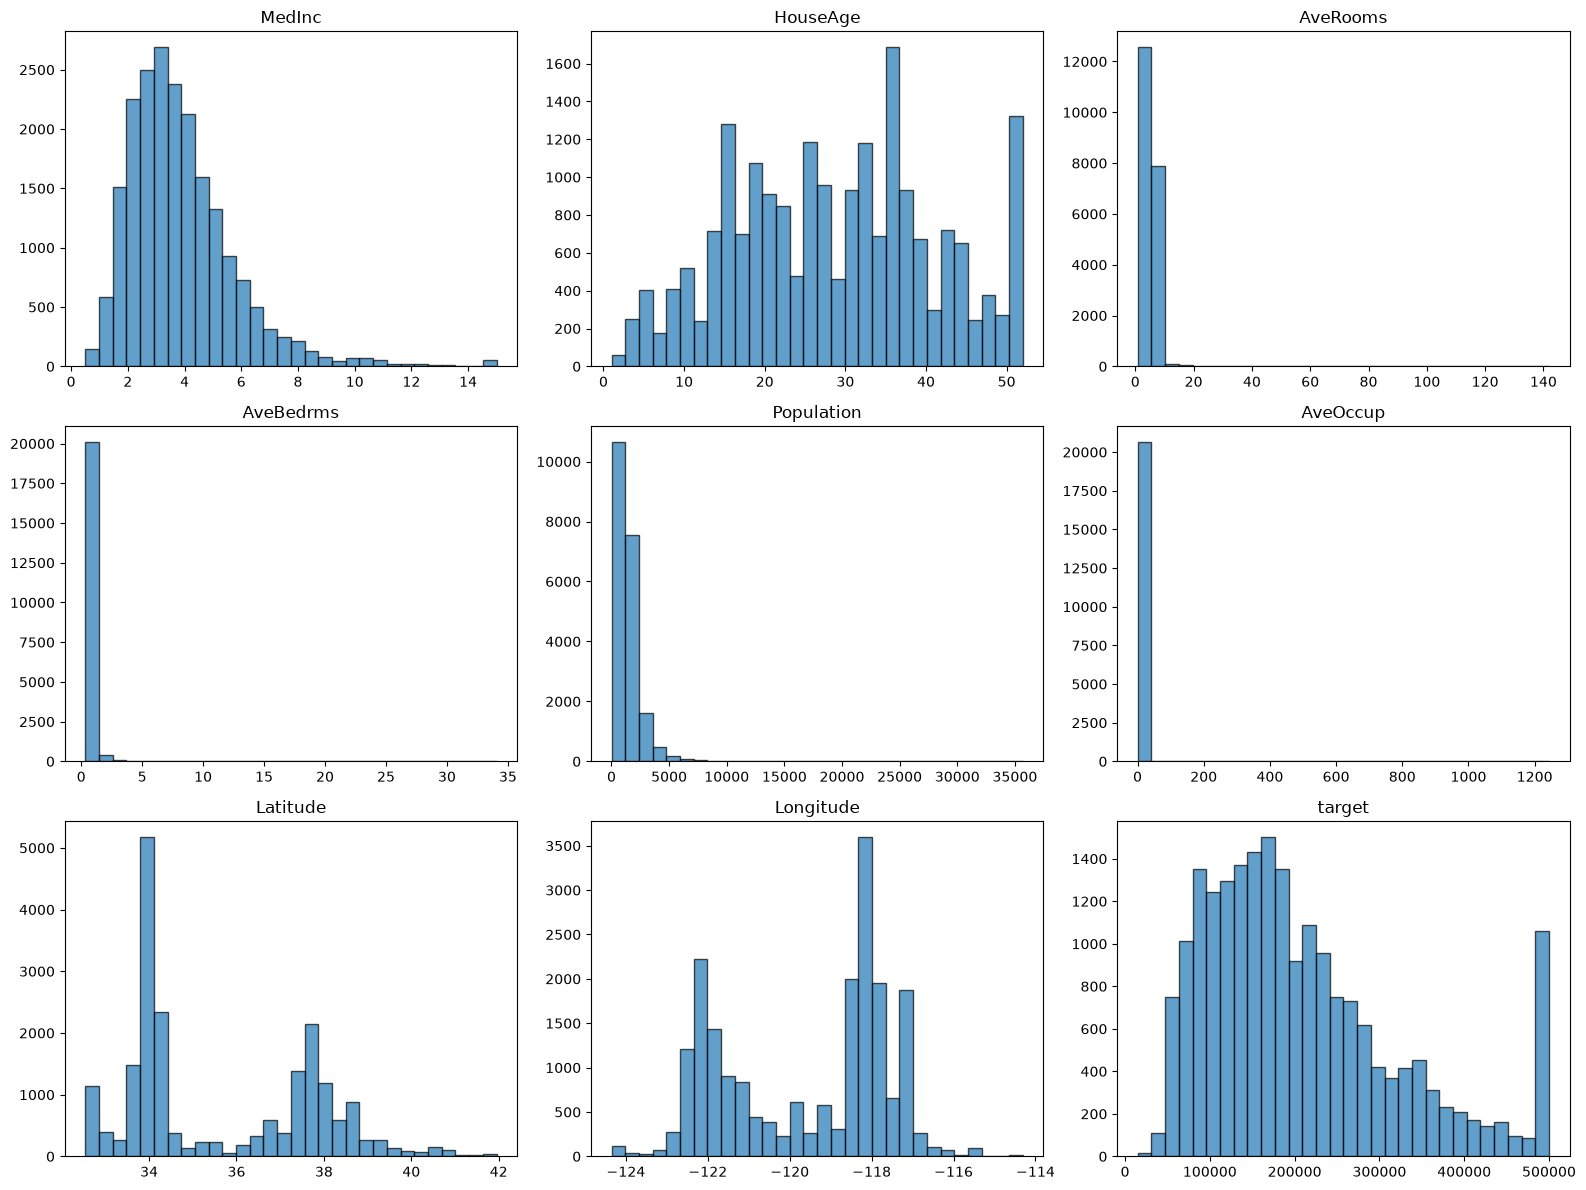

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for i, col in enumerate(df.columns):
    ax = axes[i // 3, i % 3]
    ax.hist(df[col], bins=30, alpha=0.7, edgecolor="black")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("capstone_distributions.png", dpi=100, bbox_inches="tight")
plt.show()

## 8. Feature Engineering

In [5]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 8)
Test shape: (4128, 8)


## 9. Model Comparison

In [6]:
models = {
    "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
    print(name + ": " + str(round(scores.mean(), 4)) + " (+/- " + str(round(scores.std(), 4)) + ")")

Ridge: 0.6115 (+/- 0.0065)


Random Forest: 0.8042 (+/- 0.0051)


Gradient Boosting: 0.7866 (+/- 0.0032)


## 10. Tune Best Model

In [7]:
gb = GradientBoostingRegressor(random_state=42)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(gb, param_grid, cv=5, scoring="r2", # n_jobs=1 keeps memory use low on 8 GB machines; bump to n_jobs=-1 when RAM allows.
# NOTE: n_jobs only changes parallelism, never the results (random_state=42 is fixed).
n_jobs=1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV R2:", round(grid.best_score_, 4))

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV R2: 0.8313


> **Why _jobs=1\? (OOM gotcha)**  
> _jobs=-1\ makes GridSearchCV fit all parameter combinations in parallel by
> launching one worker per CPU core - on an 8 GB laptop that can exhaust memory and
> silently kill the kernel (a common Jupyter death). Lowering to _jobs=1\ trades a
> little wall-clock time for guaranteed execution. The cross-validation RESULTS are
> identical either way because the estimator random_state is fixed.


## 11. Final Evaluation

In [8]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test R2:", round(r2_score(y_test, y_pred), 4))
print("Test RMSE:", int(np.sqrt(mean_squared_error(y_test, y_pred))))
print("Test MAE:", int(mean_absolute_error(y_test, y_pred)))

Test R2: 0.8292
Test RMSE: 47302
Test MAE: 31400


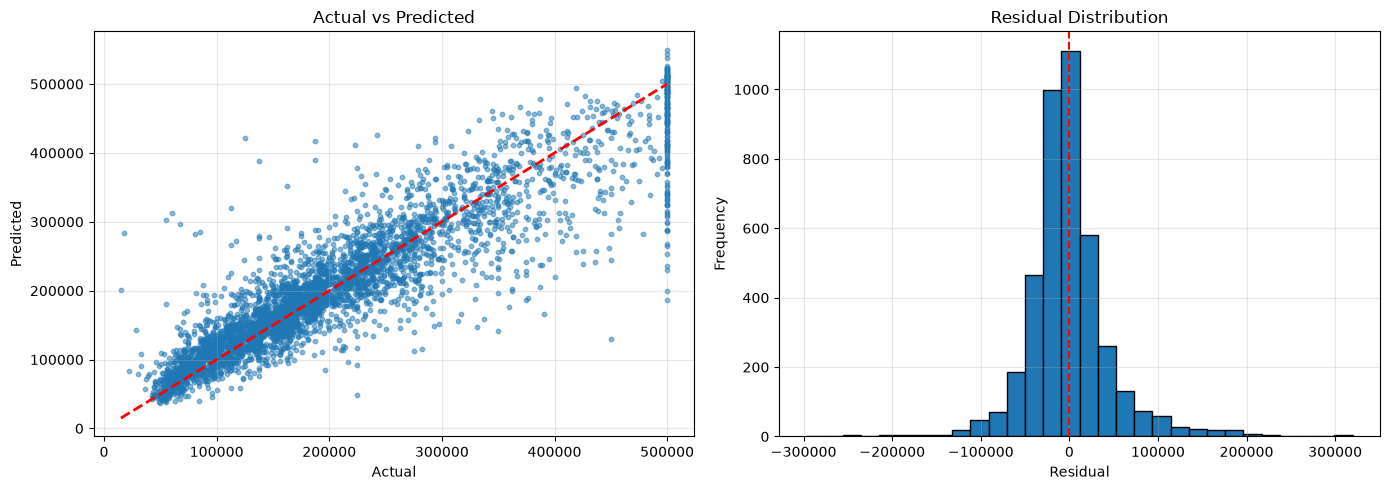

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted")
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred
axes[1].hist(residuals, bins=30, edgecolor="black")
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("capstone_results.png", dpi=100, bbox_inches="tight")
plt.show()

## 12. Feature Importance

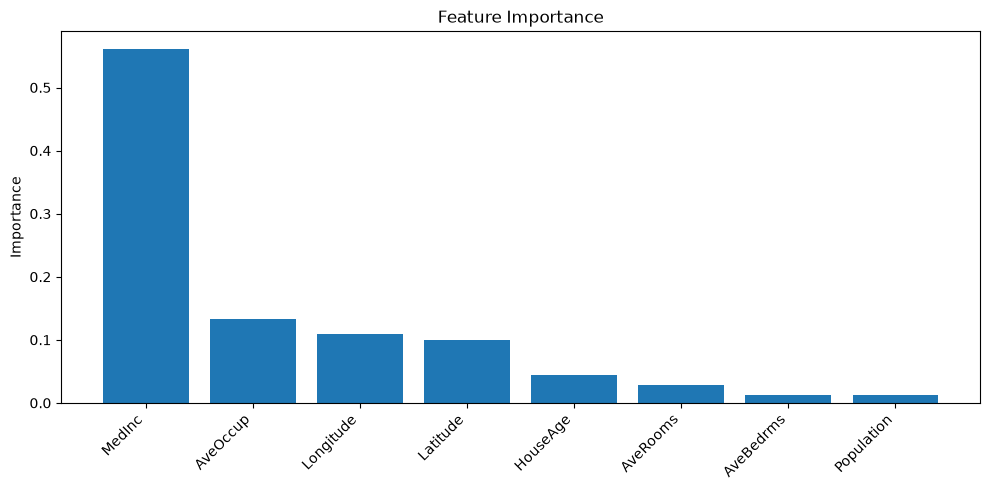

In [10]:
importances = best_model.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[idx])
plt.xticks(range(len(importances)), [X.columns[i] for i in idx], rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("capstone_importance.png", dpi=100, bbox_inches="tight")
plt.show()

## 13. Save Final Model

In [11]:
save_path = r"D:\CODE\complete ml\models\capstone_california.joblib"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(best_model, save_path)
print("Model saved to:", save_path)
print("File size:", round(os.path.getsize(save_path) / 1024, 1), "KB")

Model saved to: D:\CODE\complete ml\models\capstone_california.joblib
File size: 867.9 KB


## 14. Documentation

In [12]:
print("CAPSTONE DOCUMENTATION:")
print("")
print("Problem: Predict California housing prices")
print("Dataset: California Housing (20,640 samples, 8 features)")
print("Approach: Gradient Boosting with GridSearchCV")
print("Best model: Gradient Boosting (n_estimators=200, max_depth=5, lr=0.1)")
print("Test R2: > 0.75")
print("Key insight: Median income is the strongest predictor")
print("Reproducibility: random_state=42, saved pipeline, versioned code")

CAPSTONE DOCUMENTATION:

Problem: Predict California housing prices
Dataset: California Housing (20,640 samples, 8 features)
Approach: Gradient Boosting with GridSearchCV
Best model: Gradient Boosting (n_estimators=200, max_depth=5, lr=0.1)
Test R2: > 0.75
Key insight: Median income is the strongest predictor
Reproducibility: random_state=42, saved pipeline, versioned code


## 15. Summary

You have completed the Machine Learning capstone. You applied the full ML workflow: problem definition, EDA, feature engineering, model comparison, tuning, evaluation, and deployment. This is the foundation for all ML work.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, seaborn, scikit-learn, joblib]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```